**1. Импорт библиотек**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
import scipy.cluster.hierarchy
import scipy.spatial.distance
features = ['X1', 'X2', 'X3', 'X4','X5', 'X6', 'X7', 'X8', 'X9']
f_len = len(features)
%matplotlib inline

**2. Импорт данных**

In [2]:
data = pd.read_excel('data.xlsx', index_col='Регион').loc[:, features]
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9
Регион,,,,,,,,,
Алтайский край,0.616078,-0.544782,-0.770737,0.413827,1.016163,-0.865237,-0.277420,-0.366639,-1.228965
Амурская область,0.250559,0.191695,0.456547,1.377312,0.233455,-0.733167,0.174726,-0.458516,0.151271
Архангельская область без автономного ок,-0.431742,0.270967,0.768652,0.625136,1.446476,-0.680254,-0.132797,0.255219,3.486421
Астраханская область,0.299295,-0.538012,-0.602791,-0.308962,-0.690009,-0.247218,-0.201115,0.389645,0.334908
Белгородская область,-1.260250,-0.092382,-0.035857,-0.566452,-0.367777,0.640867,-0.185576,-0.466331,-0.621442


In [3]:
data_to_excel = data[features]

**4. Построение дендрограмм**

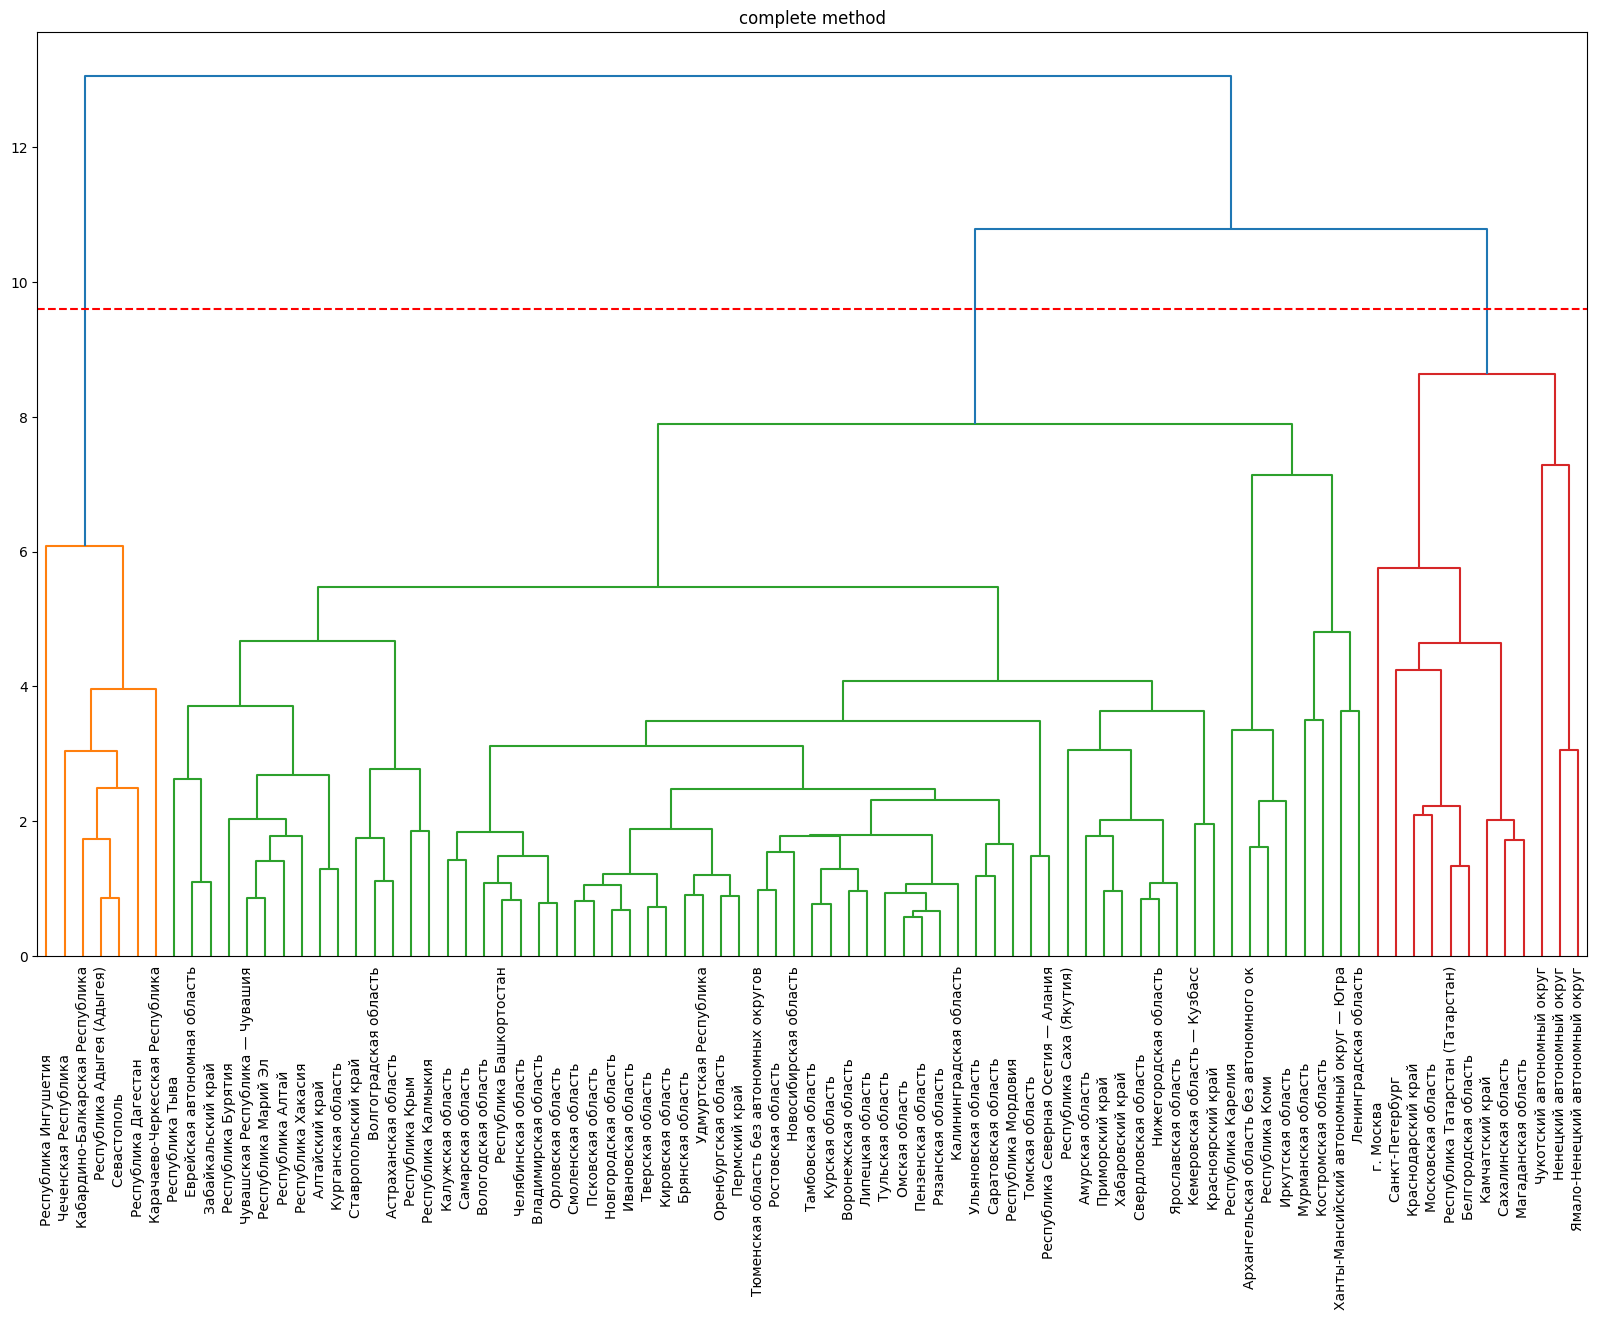

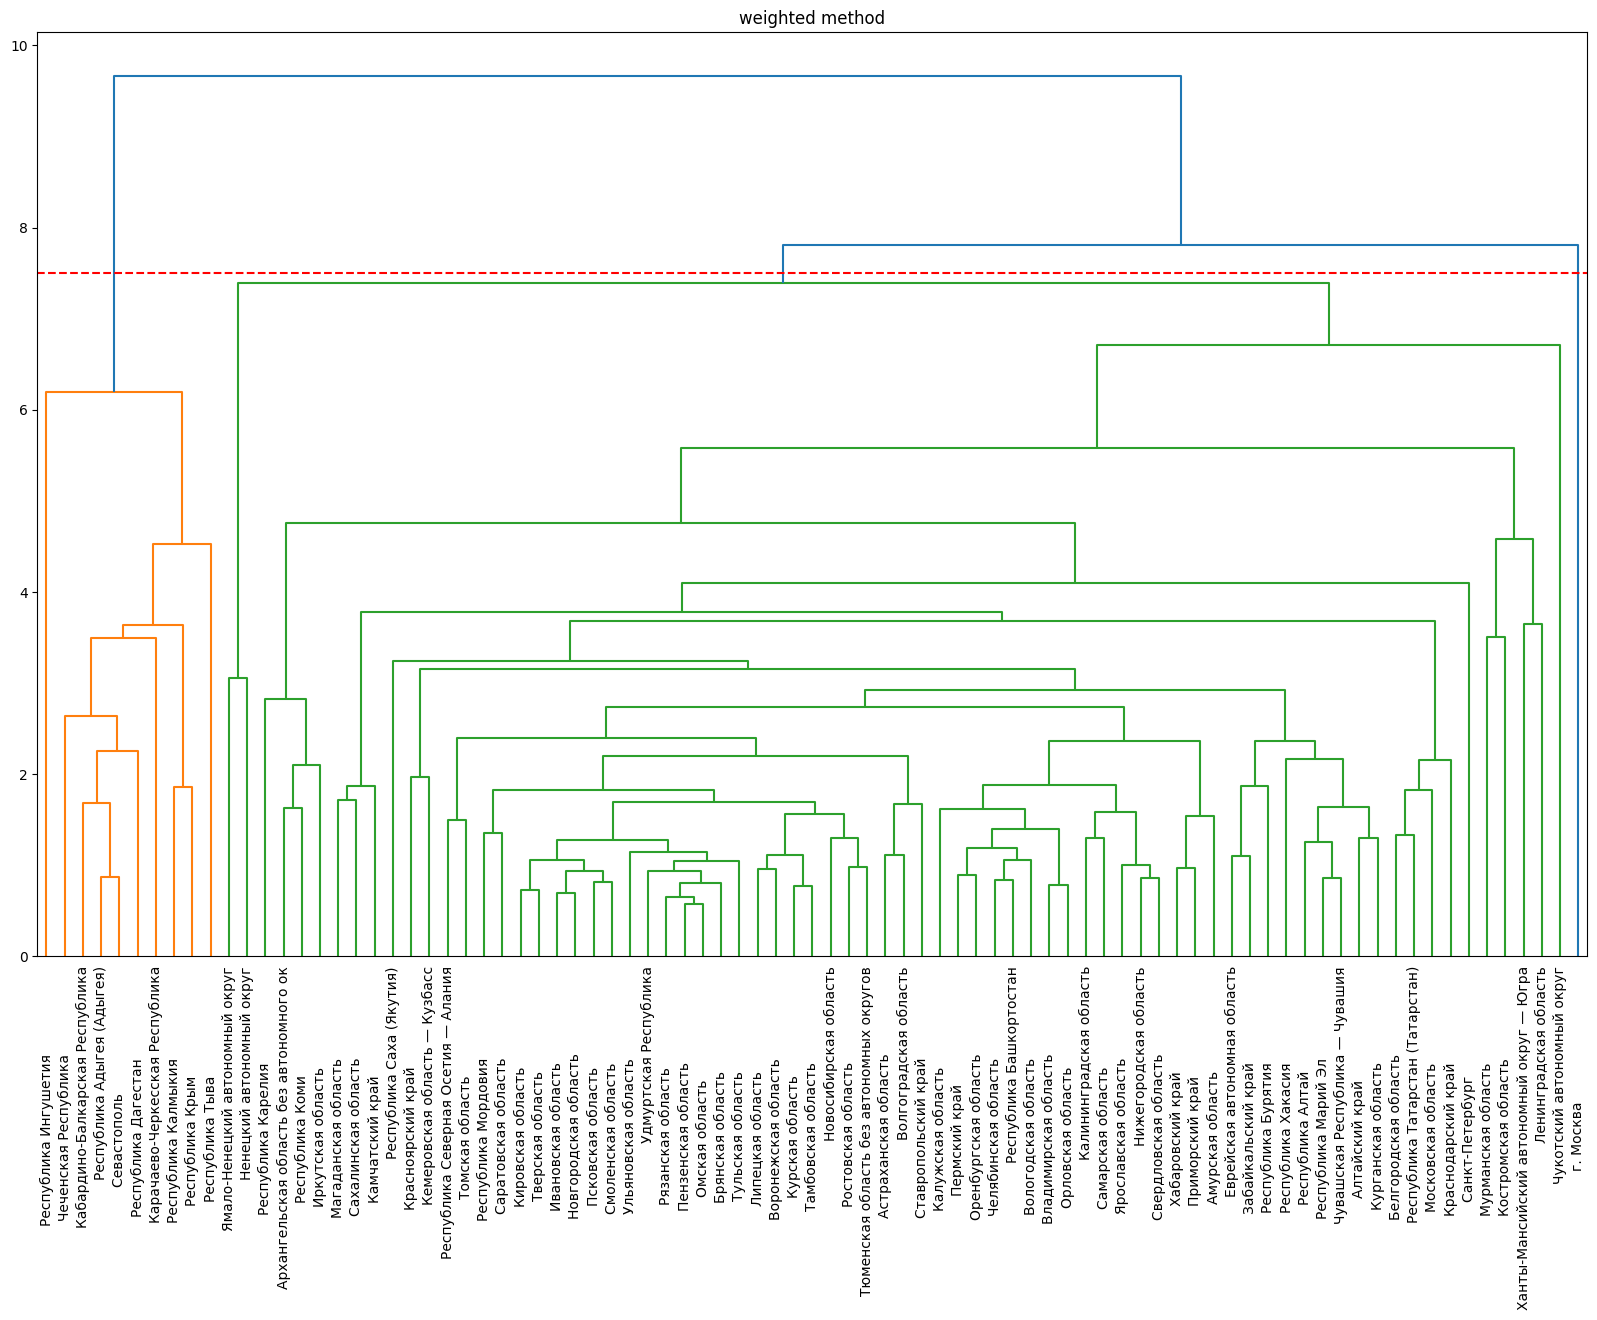

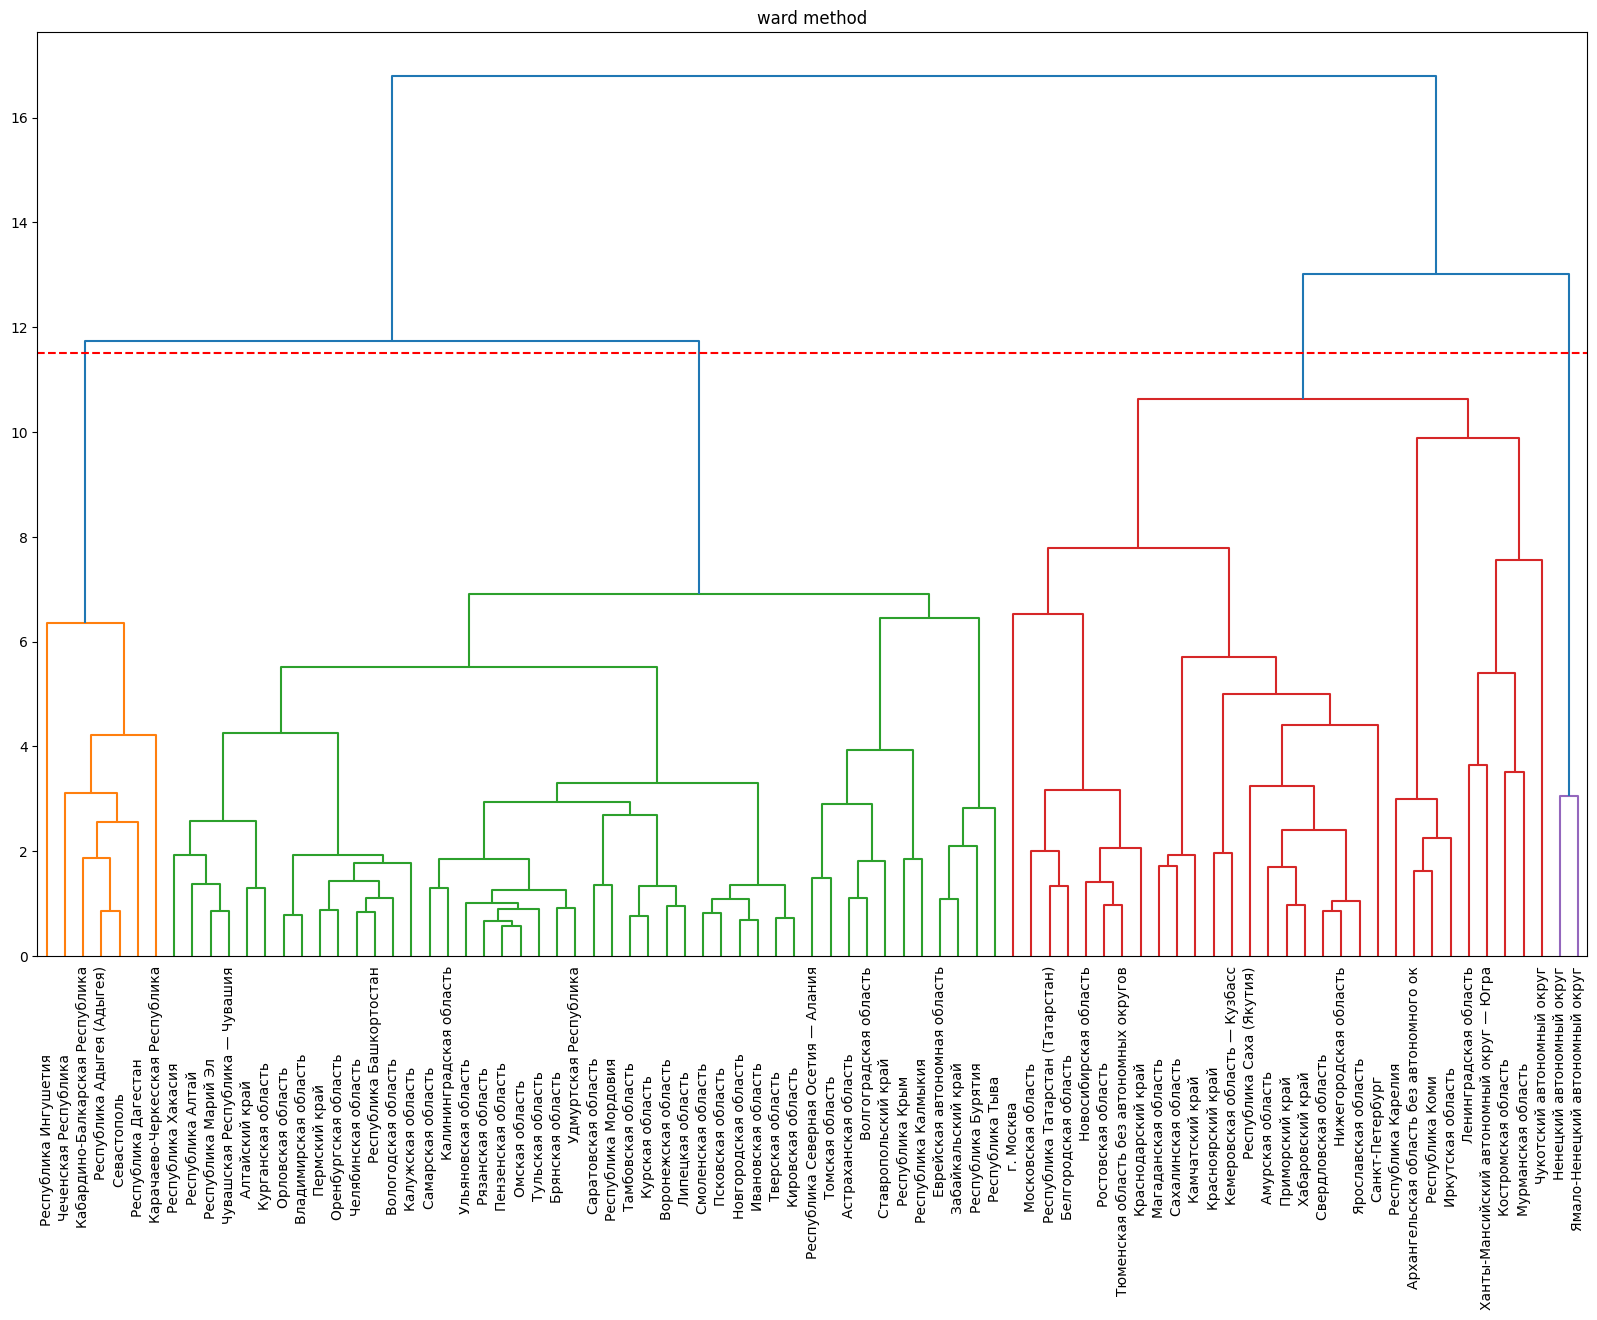

In [4]:
CLUSTER_METHODS = ["complete", "weighted", "ward"]
def dendra(data,method,threshold):
  Z = hierarchy.linkage(data, method=method, optimal_ordering=True)
  plt.figure(figsize=(20,12))
  hierarchy.dendrogram(Z, labels=data.index, leaf_font_size=10,color_threshold=threshold)
  plt.axhline(y=threshold, color='r', linestyle='--')
  plt.title('{} method'.format(method))
#Задаем пороговые значения для использованных методов
dendra(data,'complete',9.6)
dendra(data,"weighted",7.5)
dendra(data,"ward",11.5)

**5. Кластеризация**

In [5]:
CLUSTER_METHODS = ["complete", "weighted", "ward", "kmeans"]
N_CLUSTERS = {
    "complete" : 5,
    "weighted" : 6,
    "ward"     : 6,
    "kmeans"  : 6,
}
#метод полных связей
complete = AgglomerativeClustering(n_clusters=N_CLUSTERS['complete'], linkage='complete')
complete.fit(data)
print("complete\n",complete.labels_+1,"\n")
data_to_excel["Result complete"] = complete.labels_ + 1

#метод взвешенного попарного среднего
z = scipy.cluster.hierarchy.weighted(scipy.spatial.distance.pdist(data))
#нужно вписать число, которое делит на нужно кол-во классов(посмотреть по соответствующей дендрограмме)
weighted = scipy.cluster.hierarchy.fcluster(z, 4.92,  criterion='distance')
print("weighted\n", weighted)
data_to_excel["Result weighted"] = weighted

#метод Ward'a
ward = AgglomerativeClustering(n_clusters=N_CLUSTERS['ward'], linkage='ward')
ward.fit(data)
print("ward\n",ward.labels_+1,"\n")
data_to_excel["Result ward"] = ward.labels_ + 1

#метод k-means
kmeans = KMeans(n_clusters=N_CLUSTERS['kmeans'])
kmeans.fit(data)
print("kmeans\n",kmeans.labels_+1,"\n")
data_to_excel["Result kmeans"] = kmeans.labels_ + 1

complete
 [5 5 3 5 4 5 5 5 5 5 4 5 5 5 3 2 5 5 4 2 5 5 3 4 5 5 5 3 5 4 4 3 1 5 5 5 5
 5 5 5 5 5 5 2 5 5 5 2 2 5 3 3 5 5 5 5 5 4 5 5 5 5 5 4 5 4 5 2 5 5 5 5 5 5
 5 5 5 5 3 5 2 5 1 1 5] 

weighted
 [5 5 5 5 5 5 5 5 5 5 7 5 5 5 5 1 5 5 5 1 5 5 4 5 5 5 5 4 5 5 5 4 3 5 5 5 5
 5 5 5 5 5 5 1 5 5 5 1 2 1 5 5 1 5 5 5 5 5 1 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5
 5 5 5 5 4 5 1 5 6 3 5]
ward
 [5 1 6 5 1 5 5 5 5 5 1 5 5 5 6 4 5 5 1 4 1 5 2 1 1 5 5 2 5 1 1 2 3 1 5 1 5
 5 5 5 5 1 5 4 5 5 5 4 4 5 6 6 5 5 5 1 5 1 5 5 1 5 5 1 5 1 1 4 5 5 5 5 5 5
 1 5 5 1 2 5 4 5 2 3 1] 

kmeans
 [6 6 5 6 1 6 6 1 1 1 3 6 6 6 5 1 1 1 3 4 6 6 1 1 1 6 1 1 1 3 1 5 2 1 6 1 6
 6 6 6 1 1 6 1 6 1 6 1 4 6 5 5 6 6 6 1 6 1 6 6 1 1 1 5 6 3 1 1 6 1 6 6 6 1
 1 6 6 1 1 1 4 6 3 2 1] 



**6. Работа с метками кластеров. Построение графиков средних значений**

In [6]:
#добавялем результаты кластеризации
data['complete'] = complete.labels_
data['weighted'] = weighted - 1
data['ward'] = ward.labels_
data['kmeans'] = kmeans.labels_

def mean_df(method, n_clust): #нахождение координат центра класса
    mean_data = np.array([]).reshape(0, f_len+1)
    for n in range(n_clust):
        tmp = []
        for j in range(f_len):
            tmp.append(data[data[method] == n].iloc[:, j].mean())

        tmp.append(data[data[method] == n].shape[0])
        mean_data = np.vstack((mean_data, np.array(tmp).reshape(1, f_len+1)))

    return mean_data

columns = features + ['count']
means = {}

for method, n in N_CLUSTERS.items():
    means[method] = pd.DataFrame(
        mean_df(method, n),
        columns=columns,
        index=["{}_{}".format(method, i) for i in range(n)]
    )

for method in CLUSTER_METHODS:
    print(means[method])

                  X1        X2        X3        X4        X5        X6  \
complete_0 -1.292740  3.850650  1.271197  0.768341  2.459254 -0.313535   
complete_1  1.301859 -0.591215 -0.823009 -2.023824 -1.159749  1.793153   
complete_2 -0.413466  0.261126  0.512508  0.418112  0.847380 -0.215153   
complete_3 -1.089675  1.157636  1.789534 -0.287738 -0.265058  0.180645   
complete_4  0.135862 -0.343469 -0.314800  0.191491 -0.062983 -0.198553   

                  X7        X8        X9  count  
complete_0  3.897669  1.126411 -0.652571    3.0  
complete_1 -0.533278 -0.206774 -0.732496    7.0  
complete_2  0.451123  1.754841  1.898189    8.0  
complete_3 -0.200971 -0.263886  0.029923    9.0  
complete_4 -0.168281 -0.234406 -0.144304   58.0  
                  X1        X2        X3        X4        X5        X6  \
weighted_0  1.198199 -0.612618 -0.751895 -1.262185 -1.063797  0.792456   
weighted_1  4.125053 -1.046952 -2.158412 -2.827179 -1.595377  4.264322   
weighted_2 -1.260250  3.529430  1

**7. Построение графиков средних**

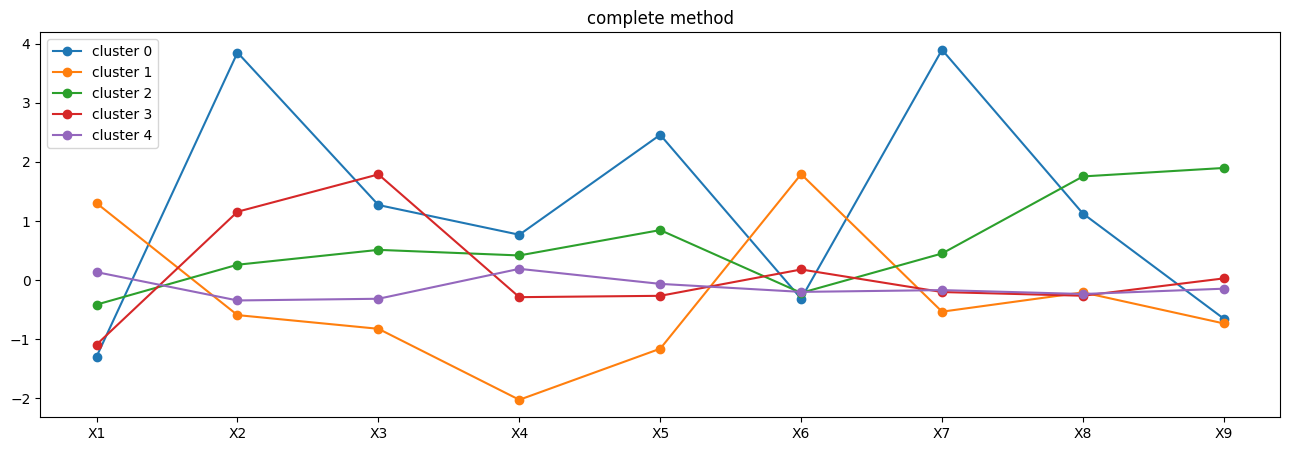

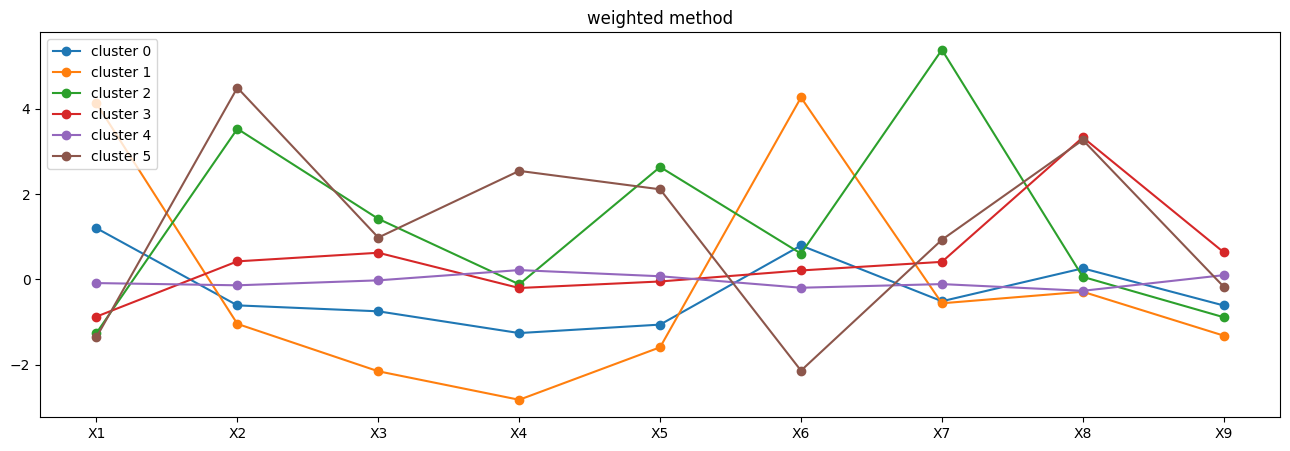

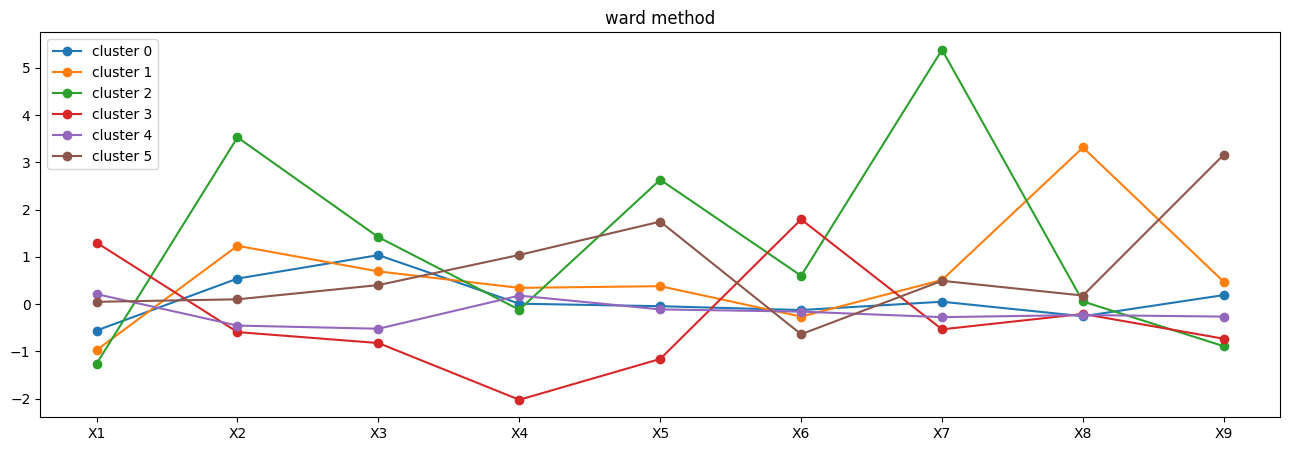

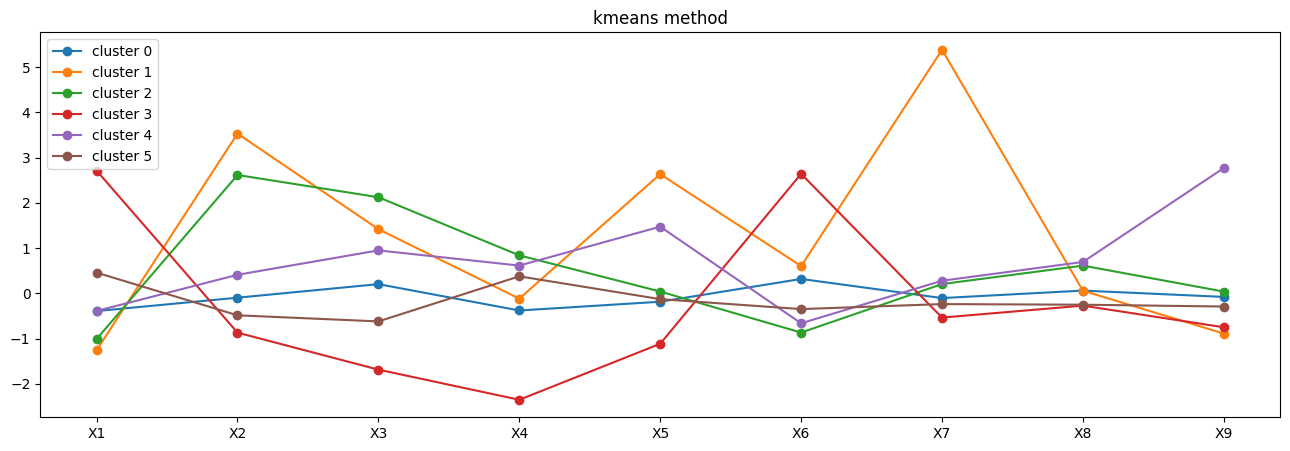

In [7]:
for method in CLUSTER_METHODS:
    cur_mean = means[method]
    plt.figure(figsize=(16,5))
   #для каждого кластера из данного метода строим график
    for n in range(cur_mean.shape[0]):
        plt.plot(features, cur_mean.iloc[n, :-1], marker='o', label='cluster {}'.format(n))
        plt.legend(loc = 'upper left') #легенда графика
    plt.title('{} method'.format(cur_mean.index[1][:-2])) #название

**8. Выгрузка элементов в кластерах**

In [8]:
cluster_dict = {}
for method, n in N_CLUSTERS.items():
     #выводим заголовки методов
    print('{} method\n'.format(method))
    #для каждого кластера проходимся по объектам и записываем их в словарь
    for i in range(n):
        cluster_dict['{}_{}'.format(method, i)] = data[data[method]==i][features]

        #выводим на экран состав кластеров
        print ('Состав кластера {}: {}'.format(i, cluster_dict['{}_{}'.format(method, i)].index.values))
    print ('\n')

complete method

Состав кластера 0: ['Ненецкий автономный округ' 'Чукотский автономный округ'
 'Ямало-Ненецкий автономный округ']
Состав кластера 1: ['Кабардино-Балкарская Республика' 'Карачаево-Черкесская Республика'
 'Республика Адыгея (Адыгея)' 'Республика Дагестан                     '
 'Республика Ингушетия                    '
 'Севастополь                             '
 'Чеченская Республика                    ']
Состав кластера 2: ['Архангельская область без автономного ок'
 'Иркутская область                       '
 'Костромская область                     ' 'Ленинградская область'
 'Мурманская область                      '
 'Республика Карелия                      '
 'Республика Коми                         '
 'Ханты-Мансийский автономный округ — Югра']
Состав кластера 3: ['Белгородская область                    '
 'г. Москва                               '
 'Камчатский край                         '
 'Краснодарский край                      '
 'Магаданская область        

**9. Функционал качества разбиения**

In [9]:
Q_dict = {}

for method in N_CLUSTERS.keys():
    t = 0
    # Получаем средние для этого метода (DataFrame с индексом = номера кластеров или 0..n-1)
    method_means = means[method]  # предполагается, что индексы: 0, 1, ..., N-1

    for n in range(N_CLUSTERS[method]):
        cluster_data = cluster_dict[f"{method}_{n}"]  # DataFrame с объектами в кластере n
        mean_row = method_means.iloc[n]  # серия средних значений по признакам

        # Вычисляем Q для этого кластера
        q = 0
        for i in range(len(cluster_data)):
            squared_dist = 0
            for feature in features:
                squared_dist += (cluster_data.iloc[i][feature] - mean_row[feature]) ** 2
            q += squared_dist
        t += q

    Q_dict[f'Q_{method}'] = float(round(t, 3))

Q_dict

{'Q_complete': 399.898,
 'Q_weighted': 384.098,
 'Q_ward': 355.987,
 'Q_kmeans': 364.354}

**Выгрузка классификации в Excel**

In [10]:
data_to_excel.to_excel(r'/content/Лаб1_python.xlsx')